# Bibliotheque

In [ ]:

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import KMeans, DBSCAN
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.utils import shuffle
from shapely.geometry import box
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import os
from sklearn_extra.cluster import KMedoids
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import AgglomerativeClustering

# READING DATA

In [3]:
df = pd.read_csv("Cleaned_dataset/grid/MERGED_UNSUPERVED_long_lat.csv")

In [4]:
df = df.drop(columns=['Unnamed: 0', 'HWSD2_SMU_ID'], errors='ignore')
print(df.columns)
print(df.shape)

Index(['longitude', 'latitude', 'COARSE', 'SAND', 'SILT', 'CLAY', 'BULK',
       'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL',
       'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ',
       'GYPSUM', 'ELEC_COND', 'elevation', 'winter_prec', 'spring_prec',
       'summer_prec', 'autumn_prec', 'winter_tmax', 'spring_tmax',
       'summer_tmax', 'autumn_tmax', 'winter_tmin', 'spring_tmin',
       'summer_tmin', 'autumn_tmin', 'GRIDCODE_14.0', 'GRIDCODE_16.0',
       'GRIDCODE_20.0', 'GRIDCODE_30.0', 'GRIDCODE_41.0', 'GRIDCODE_50.0',
       'GRIDCODE_70.0', 'GRIDCODE_100.0', 'GRIDCODE_110.0', 'GRIDCODE_120.0',
       'GRIDCODE_130.0', 'GRIDCODE_134.0', 'GRIDCODE_150.0', 'GRIDCODE_151.0',
       'GRIDCODE_170.0', 'GRIDCODE_190.0', 'GRIDCODE_200.0', 'GRIDCODE_201.0',
       'GRIDCODE_202.0', 'GRIDCODE_203.0', 'GRIDCODE_210.0', 'TEXTURE_SOTER_C',
       'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'fire_count'],
      dtype='object')
(211489, 60)


In [8]:
df

,longitude,latitude,COARSE,SAND,SILT,CLAY,BULK,REF_BULK,ORG_CARBON,PH_WATER,...,GRIDCODE_190.0,GRIDCODE_200.0,GRIDCODE_201.0,GRIDCODE_202.0,GRIDCODE_203.0,GRIDCODE_210.0,TEXTURE_SOTER_C,TEXTURE_SOTER_F,TEXTURE_SOTER_M,fire_count
0,2.178965,34.000008,0.076923,0.1250,0.142857,-0.166667,0.111111,-0.235294,-0.035336,0.142857,...,False,False,False,False,False,False,False,False,True,1.0
1,2.178965,34.000008,0.538462,1.1875,-1.428571,-0.666667,-0.777778,-0.941177,-0.018846,-0.428571,...,False,False,False,False,False,False,True,False,False,1.0
2,2.178965,34.000008,-0.153846,0.5000,-0.285714,-0.416667,-0.222223,-0.588235,-0.162544,0.142857,...,False,False,False,False,False,False,False,False,True,1.0
3,2.189793,34.000080,0.076923,0.1250,0.142857,-0.166667,0.111111,-0.235294,-0.035336,0.142857,...,False,False,False,False,False,False,False,False,True,0.0
4,2.189793,34.000080,0.538462,1.1875,-1.428571,-0.666667,-0.777778,-0.941177,-0.018846,-0.428571,...,False,False,False,False,False,False,True,False,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851948,8.952594,37.530954,-0.461538,-0.8750,-0.142857,1.333333,-1.000000,1.058823,1.416961,-1.357143,...,False,False,False,False,False,True,False,True,False,0.0
851949,8.942050,37.540488,-0.153846,2.5000,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.642858,...,False,False,False,False,False,True,True,False,False,0.0
851950,8.942050,37.540488,-0.461538,-0.8750,-0.142857,1.333333,-1.000000,1.058823,1.416961,-1.357143,...,False,False,False,False,False,True,False,True,False,0.0
851951,8.954740,37.557849,-0.153846,2.5000,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.642858,...,False,False,False,False,False,True,True,False,False,0.0


# Splitting data into (long, lat) csv and brute data csv

In [5]:
def extract_random_split_save(df, 
                              file_specific='Cleaned_dataset/unsupervised/long_lat_attributes.csv', 
                              file_rest='Cleaned_dataset/unsupervised/data.csv'):
    
    specific_attributes = ['longitude', 'latitude']
    
    missing_cols = [col for col in specific_attributes if col not in df.columns]
    if missing_cols:
        print(f"Error: The following columns are missing from the data: {missing_cols}")
        return

    df_specific = df[specific_attributes]
    
    df_rest = df.drop(columns=specific_attributes)
    
    df_specific.to_csv(file_specific, index=False)
    df_rest.to_csv(file_rest, index=False)
    
    print(f"Process Complete.")
    print(f"Total rows in original: {len(df)}")
    print(f"Rows in sample (100%): {len(df)}")
    print(f"Saved specific columns to: {file_specific}")
    print(f"Saved rest of data to: {file_rest}")



In [6]:
extract_random_split_save(df)
data_df = pd.read_csv('Cleaned_dataset/unsupervised/data.csv')
long_lat_df = pd.read_csv('Cleaned_dataset/unsupervised/long_lat_attributes.csv')

Process Complete.
Total rows in original: 211489
Rows in sample (100%): 211489
Saved specific columns to: Cleaned_dataset/unsupervised/long_lat_attributes.csv
Saved rest of data to: Cleaned_dataset/unsupervised/data.csv


In [7]:
print(data_df.shape)
print(long_lat_df.shape)

(211489, 58)
(211489, 2)


# KMEANS REDUCTION

In [ ]:
def unsupervised_feature_reduction_kmeans(csv_path, var_threshold=0.01, cluster_distance=0.2,):
    df = pd.read_csv(csv_path)

    if "fire" in df.columns:
        df = df.drop(columns=["fire"])

    print(f"Initial features: {df.shape[1]}")
 
    selector = VarianceThreshold(threshold=var_threshold)
    selector.fit(df)
    df = df.loc[:, selector.get_support()]
    print(f"After Variance Filter: {df.shape[1]}")
 
    corr_matrix = df.corr().abs()
    distance_matrix = 1 - corr_matrix

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=cluster_distance,
        compute_distances=True,
    )
    clustering.fit(distance_matrix)
    cluster_labels = clustering.labels_

    selected_features = []
    for cluster_id in np.unique(cluster_labels):
        cluster_features = df.columns[cluster_labels == cluster_id]
        if len(cluster_features) == 1:
            selected_features.append(cluster_features[0])
        else:
            cluster_corr = corr_matrix.loc[cluster_features, cluster_features]
            best_feature = cluster_corr.sum().idxmax()
            selected_features.append(best_feature)

    df = df[selected_features]
    print(f"After Clustering: {df.shape[1]}")

    return df

df = unsupervised_feature_reduction_kmeans(csv_path="Cleaned_dataset/unsupervised/data.csv")
print(df.shape)
print(df.columns)


Initial features: 58
After Variance Filter: 47
After Clustering: 32
(211489, 32)
Index(['PH_WATER', 'ORG_CARBON', 'CN_RATIO', 'CLAY', 'GRIDCODE_200.0',
       'fire_count', 'elevation', 'spring_tmin', 'CEC_EFF', 'GRIDCODE_130.0',
       'GRIDCODE_20.0', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'spring_tmax',
       'TEXTURE_SOTER_C', 'ESP', 'GRIDCODE_201.0', 'GRIDCODE_150.0', 'COARSE',
       'ALUM_SAT', 'autumn_prec', 'SILT', 'summer_prec', 'GRIDCODE_14.0',
       'GRIDCODE_151.0', 'BULK', 'winter_prec', 'GRIDCODE_30.0', 'CEC_CLAY',
       'GRIDCODE_50.0', 'spring_prec', 'GRIDCODE_110.0'],
      dtype='object')


# KMEANS

DATA SHAPE: (211489, 32)
K range: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

################################################################################
TRAINING KMEANS | K = 3
################################################################################
→ Fitting model on FULL dataset...
✓ Training completed
→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 0.5333
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 231986.8108
→ Silhouette evaluation on 4 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.6902
  Subset 2 | random_state=43
    Silhouette score: 0.6886
  Subset 3 | random_state=44
    Silhouette score: 0.6876
  Subset 4 | random_state=45
    Silhouette score: 0.6921
→ Average Silhouette (K=3): 0.6897
→ Saving clustered dataset...
✓ CSV saved: kmeans_models_outputs\data_kmeans_k3.csv

################################################################################
TRAINING KMEANS | K = 4
###################################

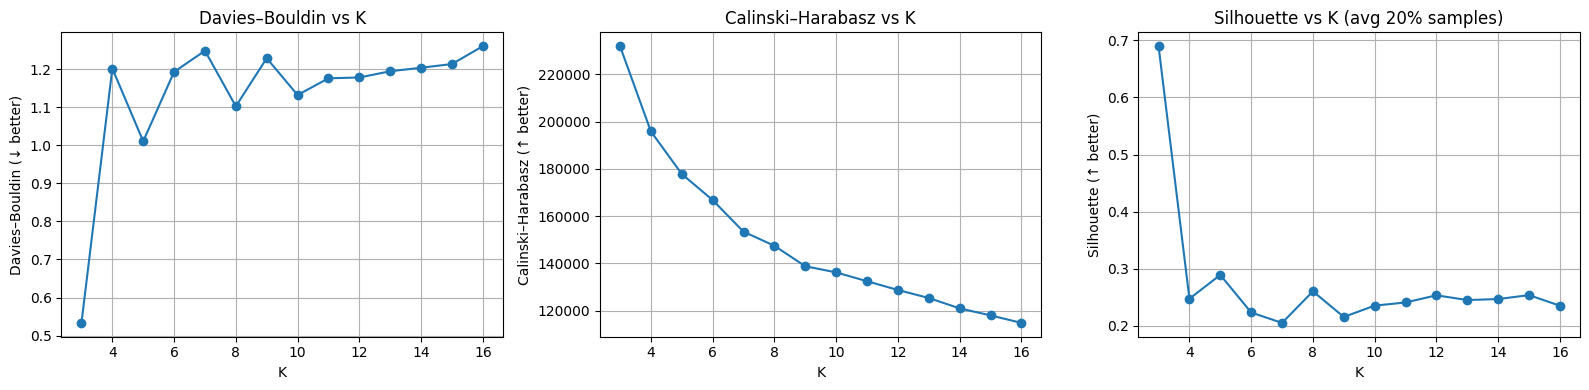

In [ ]:

OUTPUT_DIR = "kmeans_models_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

K_RANGE = range(3, 17)
SILHOUETTE_SAMPLE_RATIO = 0.20
SILHOUETTE_REPEATS = 4
BASE_RANDOM_STATE = 42

X = df.values  # ensure numpy array

print("=" * 80)
print(f"DATA SHAPE: {X.shape}")
print(f"K range: {list(K_RANGE)}")
print("=" * 80)

results = []

# ==============================
# MAIN LOOP
# ==============================
for k in K_RANGE:
    print("\n" + "#" * 80)
    print(f"TRAINING KMEANS | K = {k}")
    print("#" * 80)

    # --------------------------
    # Train on FULL DATA
    # --------------------------
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=BASE_RANDOM_STATE
    )

    print("→ Fitting model on FULL dataset...")
    labels_full = kmeans.fit_predict(X)
    print("✓ Training completed")

    # --------------------------
    # Internal metrics (FULL DATA)
    # --------------------------
    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    # --------------------------
    # Silhouette (SUBSAMPLING)
    # --------------------------
    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
        rs = BASE_RANDOM_STATE + i
        print(f"  Subset {i+1} | random_state={rs}")

        X_sub, labels_sub = shuffle(
            X, labels_full, random_state=rs
        )

        X_sub = X_sub[:sample_size]
        labels_sub = labels_sub[:sample_size]

        sil = silhouette_score(
            X_sub, labels_sub, metric="euclidean"
        )

        silhouette_scores.append(sil)
        print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")

    # --------------------------
    # Save clustered CSV
    # --------------------------
    print("→ Saving clustered dataset...")

    clustered_df = df.copy()
    clustered_df["cluster"] = labels_full

    output_path = os.path.join(
        OUTPUT_DIR, f"data_kmeans_k{k}.csv"
    )
    clustered_df.to_csv(output_path, index=False)

    print(f"✓ CSV saved: {output_path}")

    # --------------------------
    # Store results
    # --------------------------
    results.append({
        "k": k,
        "davies_bouldin": db_index,
        "calinski_harabasz": ch_index,
        "silhouette_avg": silhouette_avg
    })

# ==============================
# FINAL SUMMARY TABLE
# ==============================
results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("FINAL METRICS SUMMARY")
print("=" * 80)
print(results_df)

summary_path = os.path.join(OUTPUT_DIR, "kmeans_metrics_summary.csv")
results_df.to_csv(summary_path, index=False)

print("\n✓ Metrics summary saved to:", summary_path)
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))

# Davies-Bouldin
plt.subplot(1, 3, 1)
plt.plot(results_df["k"], results_df["davies_bouldin"], marker="o")
plt.title("Davies–Bouldin vs K")
plt.xlabel("K")
plt.ylabel("Davies–Bouldin (↓ better)")
plt.grid(True)

# Calinski-Harabasz
plt.subplot(1, 3, 2)
plt.plot(results_df["k"], results_df["calinski_harabasz"], marker="o")
plt.title("Calinski–Harabasz vs K")
plt.xlabel("K")
plt.ylabel("Calinski–Harabasz (↑ better)")
plt.grid(True)

# Silhouette
plt.subplot(1, 3, 3)
plt.plot(results_df["k"], results_df["silhouette_avg"], marker="o")
plt.title("Silhouette vs K (avg 20% samples)")
plt.xlabel("K")
plt.ylabel("Silhouette (↑ better)")
plt.grid(True)

plt.tight_layout()
plt.show()


## plotting kmeans clusters on the map

In [ ]:
 
coords = pd.read_csv("Cleaned_dataset/unsupervised/long_lat_attributes.csv")
lat_col = [c for c in coords.columns if 'lat' in c.lower()][0]
lon_col = [c for c in coords.columns if 'lon' in c.lower() or 'long' in c.lower()][0]
 
world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(world_url)
countries = world[world['name'].isin(["Algeria", "Tunisia"])]
 
xmin, ymin, xmax, ymax = countries.total_bounds
clipping_rect = box(xmin, 34, xmax, 40) 
countries_clipped = countries.clip(clipping_rect)

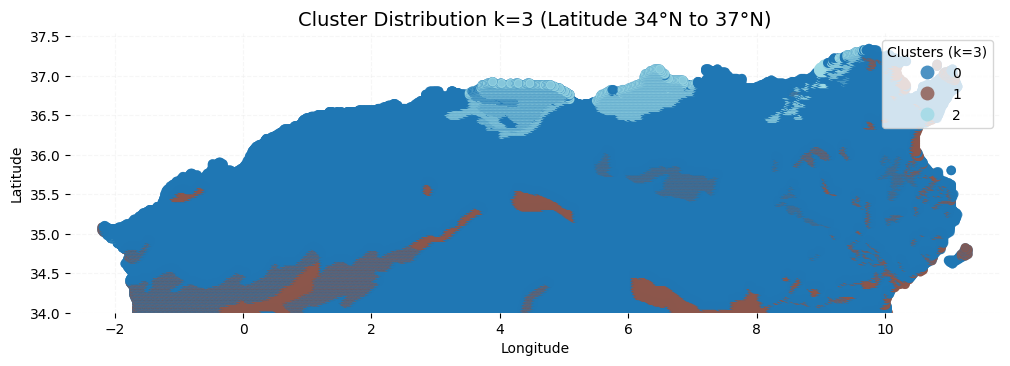

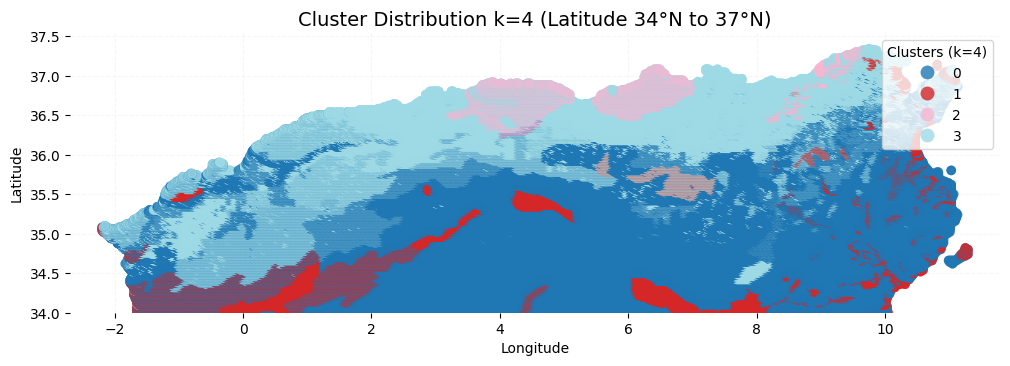

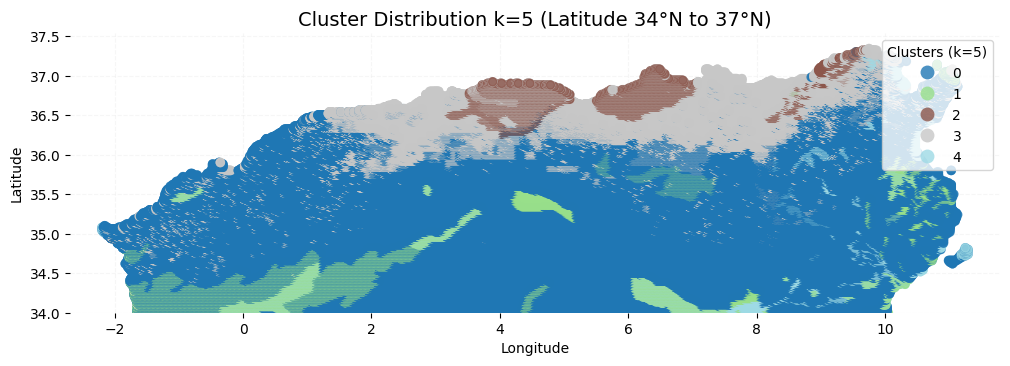

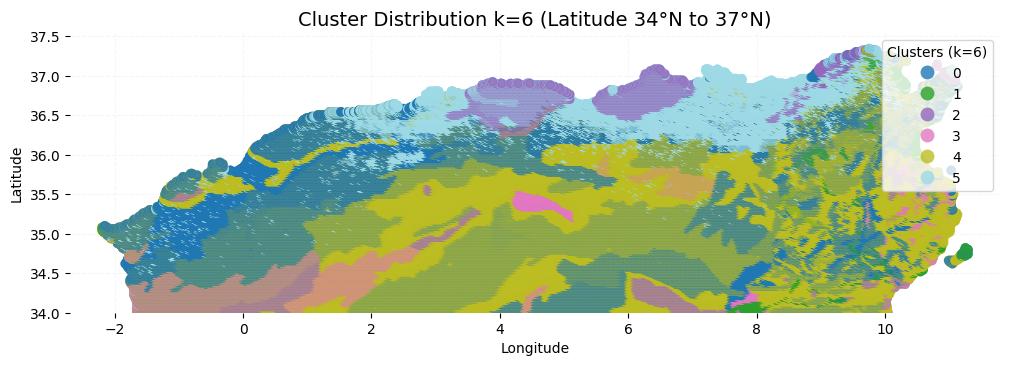

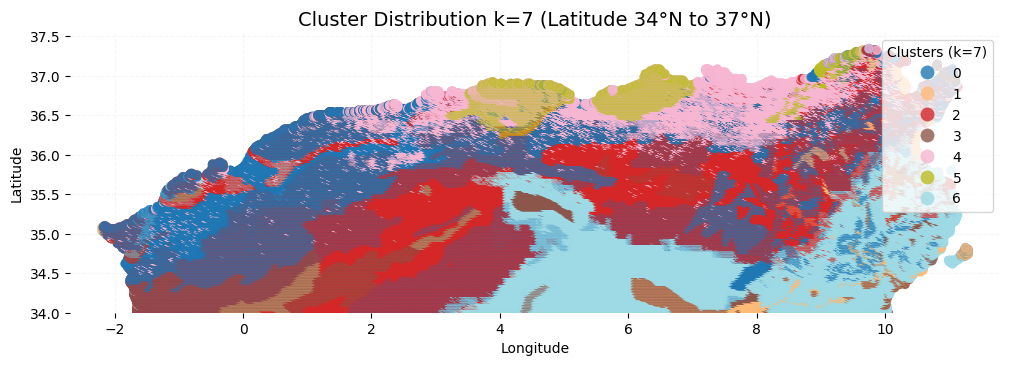

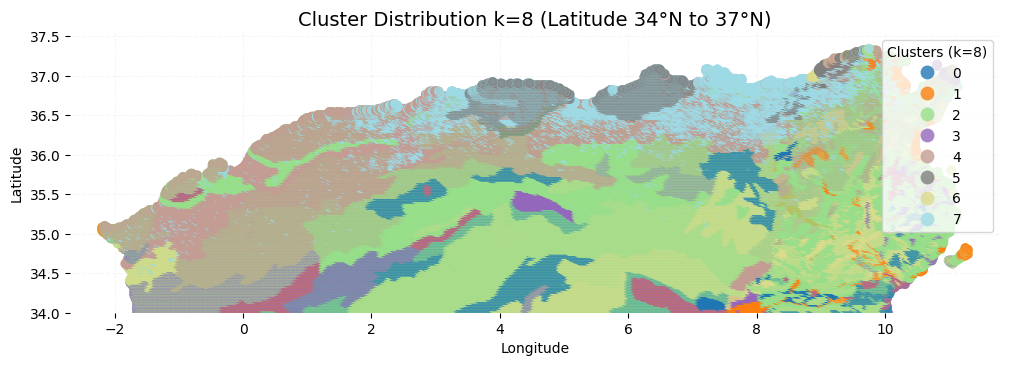

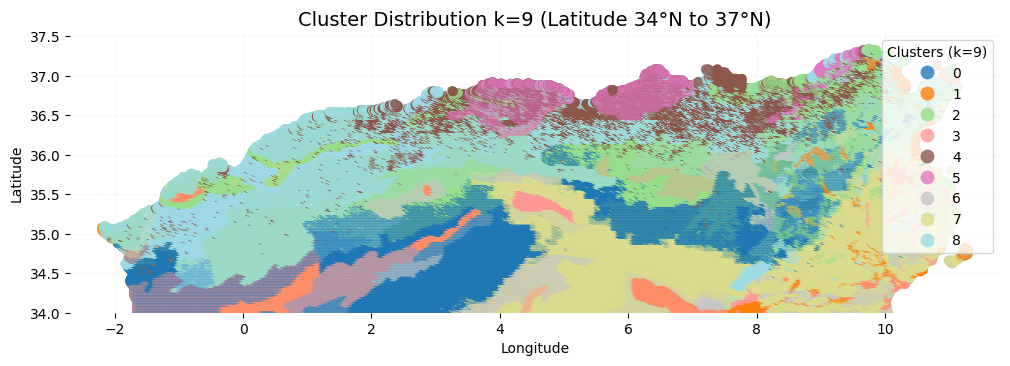

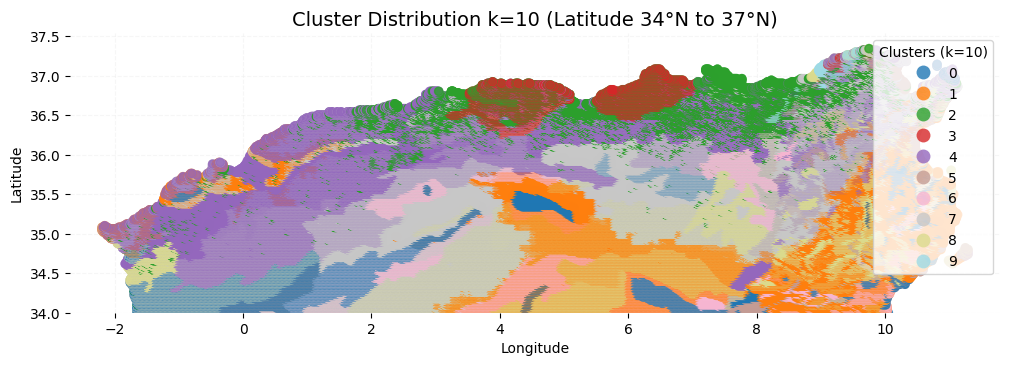

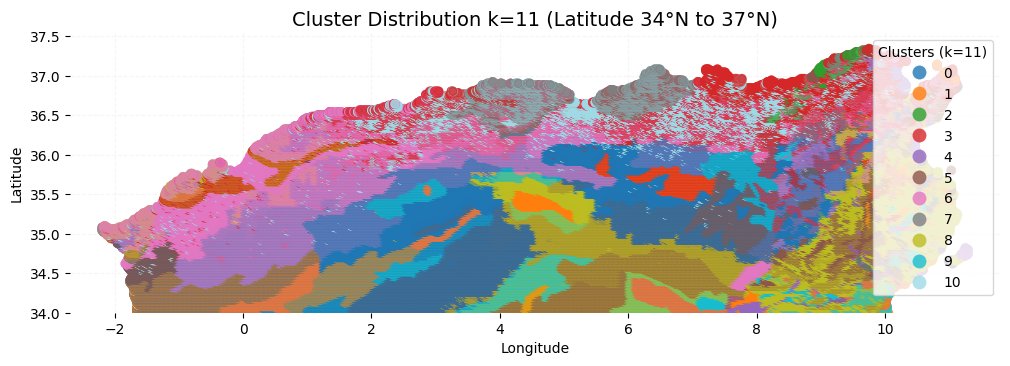

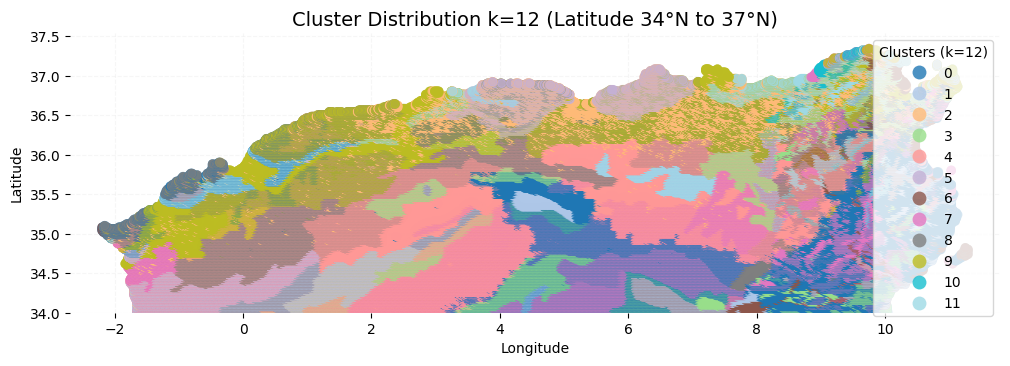

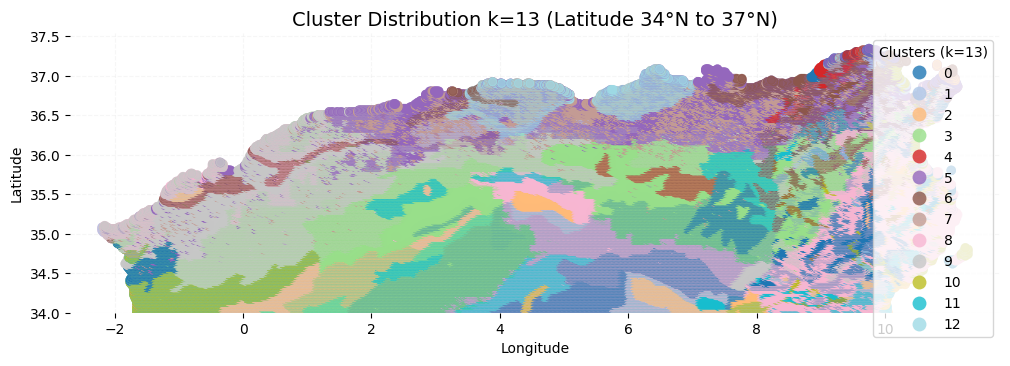

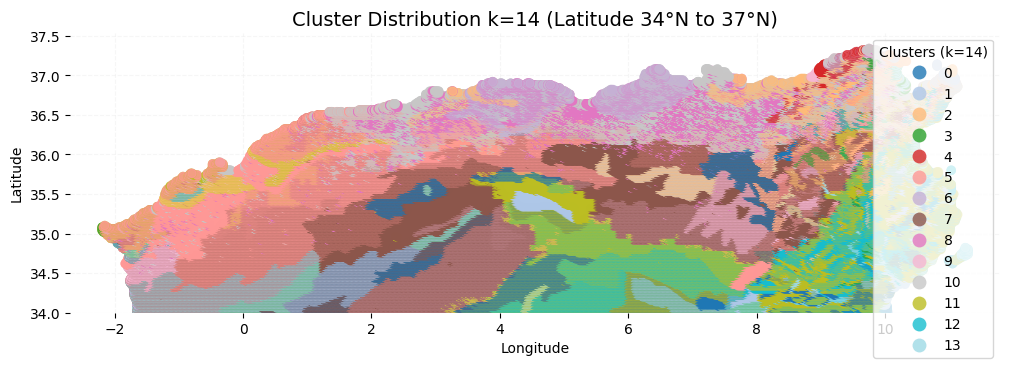

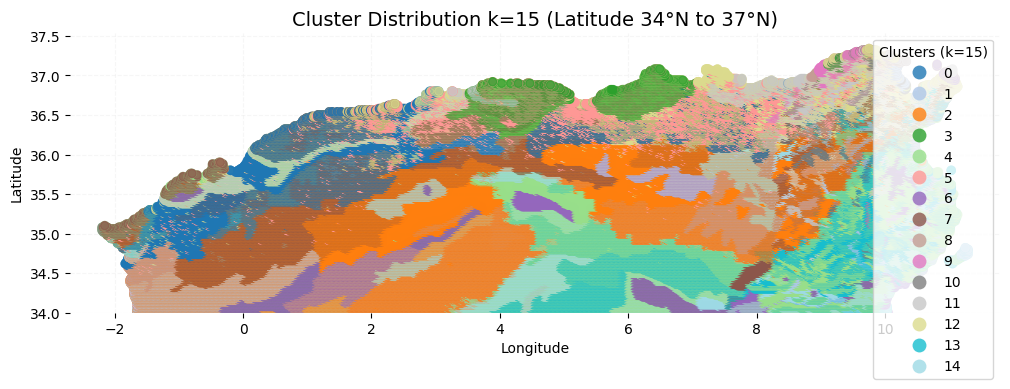

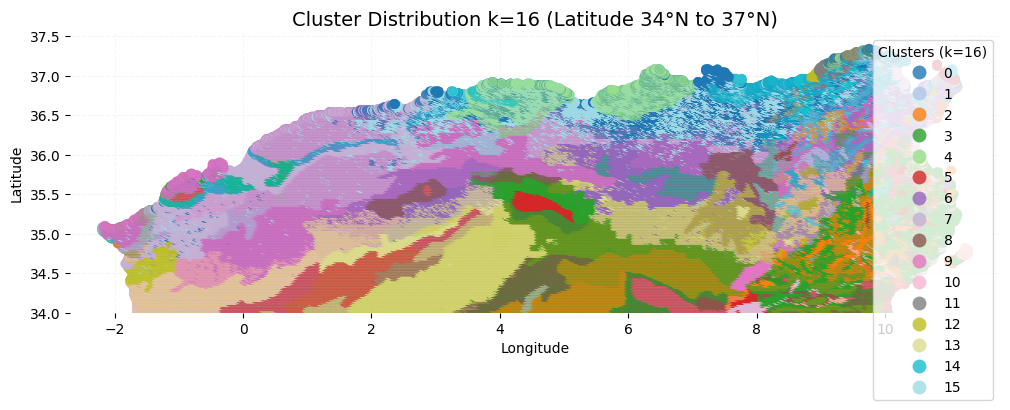

In [ ]:
 
for k in range(3, 17):
    file_path = f"kmeans_models_outputs/data_kmeans_k{k}.csv"
    
    # Check if file exists
    if not os.path.exists(file_path):
        continue

    # Load specific cluster file
    clusters = pd.read_csv(file_path)

    # Combine
    df = pd.concat([coords, clusters[['cluster']]], axis=1)

    # 4. Filter strictly for Latitude > 34
    df_filtered = df[df[lat_col] > 34].copy()

    # 5. Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
        crs="EPSG:4326"
    )

    # 6. Plotting (Exact style from your code)
    fig, ax = plt.subplots(figsize=(12, 12)) 

    # NO BLACK: Land is white, borders are invisible
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)

    # Plot the clusters 
    # (Using tab20 because you have up to 16 clusters)
    gdf.plot(column='cluster', 
             ax=ax, 
             categorical=True, 
             legend=True, 
             cmap='tab20', 
             markersize=35,      
             alpha=0.8,          
             zorder=2,
             legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})

    # 7. VIEWPORT LOGIC: FORCE 34 to Max Lat
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)

    # Remove all black frame lines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Styling
    plt.title(f"Cluster Distribution k={k} (Latitude 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Light grid
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)

    plt.show()

In [16]:
data_df = pd.read_csv('Cleaned_dataset/unsupervised/data.csv')

In [17]:
data_df

,COARSE,SAND,SILT,CLAY,BULK,REF_BULK,ORG_CARBON,PH_WATER,TOTAL_N,CN_RATIO,...,GRIDCODE_190.0,GRIDCODE_200.0,GRIDCODE_201.0,GRIDCODE_202.0,GRIDCODE_203.0,GRIDCODE_210.0,TEXTURE_SOTER_C,TEXTURE_SOTER_F,TEXTURE_SOTER_M,fire_count
0,-0.615385,-0.466667,1.142857,0.000000,0.555555,-0.058823,-0.037691,0.133333,-0.018518,-0.333333,...,False,False,True,False,False,False,False,False,True,1.0
1,0.538462,1.266667,-1.428571,-0.666667,-0.777778,-0.941177,-0.018846,-0.400000,-0.648148,1.000000,...,False,False,True,False,False,False,True,False,False,1.0
2,0.076923,0.666667,-0.714286,-0.333333,-0.111112,-0.411765,-0.130742,-0.133333,-0.370370,-0.333333,...,False,False,True,False,False,False,False,False,True,1.0
3,0.384615,0.000000,-0.285714,0.250000,-0.222223,0.235294,-0.214370,0.200000,-0.574074,0.333333,...,False,False,True,False,False,False,False,False,True,1.0
4,-0.615385,-0.466667,1.142857,0.000000,0.555555,-0.058823,-0.037691,0.133333,-0.018518,-0.333333,...,False,False,True,False,False,False,False,False,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211484,-0.153846,2.666667,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.533333,-0.759259,1.000000,...,False,False,False,False,False,False,True,False,False,1.0
211485,0.538462,-0.466667,0.571429,0.333333,-0.222223,0.294117,0.531213,0.000000,-0.092593,-0.333333,...,False,False,False,False,False,False,False,False,True,1.0
211486,-0.153846,-0.466667,0.571429,0.333333,-0.222223,0.294117,0.435218,-1.133333,-0.092593,0.166667,...,False,False,False,False,False,True,False,False,True,0.0
211487,-0.153846,2.666667,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.533333,-0.759259,1.000000,...,False,False,False,False,False,False,True,False,False,0.0


# REDUCTION FOR DBSCAN + HDBSCAN + CLARA (10-15 features)

In [ ]:
def unsupervised_feature_reduction(csv_path,output_path,var_threshold=0.01,cluster_distance=0.3,use_autoencoder=False,n_ae_features=10,ae_epochs=50,percentage_data=1,):
    df = pd.read_csv(csv_path)

    if "fire" in df.columns:
        df = df.drop(columns=["fire"])
    df = df.sample(frac=percentage_data, random_state=42)
    print(f"Initial features: {df.shape[1]}")

    # ------------------------------------------------------------
    # 1️⃣ Remove Low-variance features
    # ------------------------------------------------------------
    selector = VarianceThreshold(threshold=var_threshold)
    selector.fit(df)
    df = df.loc[:, selector.get_support()]
    print(f"After Variance Filter: {df.shape[1]}")

    # ------------------------------------------------------------
    # 2️⃣ Feature Clustering
    # ------------------------------------------------------------
    corr_matrix = df.corr().abs()
    distance_matrix = 1 - corr_matrix

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=cluster_distance,
        compute_distances=True,
    )
    clustering.fit(distance_matrix)
    cluster_labels = clustering.labels_

    selected_features = []
    for cluster_id in np.unique(cluster_labels):
        cluster_features = df.columns[cluster_labels == cluster_id]
        if len(cluster_features) == 1:
            selected_features.append(cluster_features[0])
        else:
            cluster_corr = corr_matrix.loc[cluster_features, cluster_features]
            best_feature = cluster_corr.sum().idxmax()
            selected_features.append(best_feature)

    df = df[selected_features]
    print(f"After Clustering: {df.shape[1]}")

    # ------------------------------------------------------------
    # 3️⃣ Optional: Autoencoder
    # ------------------------------------------------------------
    if use_autoencoder:
        print("Starting Autoencoder compression...")

        # Ensure the data is numeric and float32 for Keras
        try:
            X_input = df.astype("float32").values
        except ValueError as e:
            print("\n❌ DATA ERROR FOUND!")
            print("One column contains non-numeric data.")
            print("Run: print(df.dtypes[df.dtypes == 'object'])")
            raise e

        input_dim = X_input.shape[1]

        # ---------------------------
        # Autoencoder Architecture
        # ---------------------------

        input_layer = Input(shape=(input_dim,))

        # Encoder (deep encoder → better compression)
        e = Dense(128, activation="relu")(input_layer)
        e = Dense(64, activation="relu")(e)
        bottleneck = Dense(n_ae_features, activation="linear")(e)

        # Decoder (mirroring encoder)
        d = Dense(64, activation="relu")(bottleneck)
        d = Dense(128, activation="relu")(d)

        # *** IMPORTANT ***
        # Use linear output because your data includes StandardScaler features
        output_layer = Dense(input_dim, activation="linear")(d)

        # Build models
        autoencoder = Model(inputs=input_layer, outputs=output_layer)
        encoder = Model(inputs=input_layer, outputs=bottleneck)

        autoencoder.compile(optimizer="adam", loss="mse")

        # ---------------------------
        # Training (with validation)
        # ---------------------------

        history = autoencoder.fit(
            X_input,
            X_input,
            epochs=ae_epochs,
            batch_size=32,
            shuffle=True,
            validation_split=0.1,
            verbose=1,
        )

        plt.plot(history.history["loss"], label="train")
        plt.plot(history.history["val_loss"], label="val")
        plt.legend()
        plt.title("Autoencoder Reconstruction Loss")
        plt.show()

        # ---------------------------
        # Encode & Replace DF
        # ---------------------------

        encoded_data = encoder.predict(X_input)

        feat_cols = [f"ae_feature_{i}" for i in range(n_ae_features)]
        df = pd.DataFrame(encoded_data, columns=feat_cols)

        print(f"After Autoencoder: {df.shape[1]} synthetic features")

    df.to_csv(output_path, index=False)
    print(f"Saved to {output_path}")



Initial features: 58
After Variance Filter: 47
After Clustering: 32
Starting Autoencoder compression...
Epoch 1/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0338 - val_loss: 0.0151
Epoch 2/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0124 - val_loss: 0.0092
Epoch 3/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0092 - val_loss: 0.0076
Epoch 4/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 5/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 955us/step - loss: 0.0059 - val_loss: 0.0046
Epoch 6/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 945us/step - loss: 0.0050 - val_loss: 0.0042
Epoch 7/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 985us/step - loss: 0.0044 - val_loss: 0.0035
Epoch 8/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 942us/step - loss: 0.0040 - val_loss: 0.0033
Epoch 9/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 955us/step - loss: 0.0036 - val_loss: 0.0033
Epoch 10/50
5949/5949 ━━━━━━━━━━━━━━━━━━━━ 6s 986us/step - loss: 0.0038 - val_loss: 0.0032
Epo

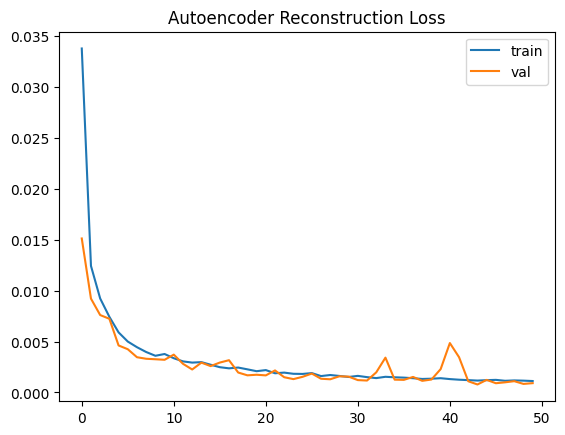

6610/6610 ━━━━━━━━━━━━━━━━━━━━ 3s 522us/step
After Autoencoder: 10 synthetic features
Saved to Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_10.csv


In [3]:

nb_features = 10
unsupervised_feature_reduction(
    csv_path="Cleaned_dataset/unsupervised/data.csv",
    output_path=f"Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_{nb_features}.csv",
    var_threshold=0.01,
    cluster_distance=0.2,
    use_autoencoder=True,
    n_ae_features=nb_features,
    ae_epochs=50,
)

# DBSCAN + HDBSCAN

In [20]:
INPUT_CSV = "Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_10.csv"
OUTPUT_DIR = "dbscan_models_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# PARAMÈTRES À TESTER (OPTIMISÉS POUR 800k x 10)
EPS_RANGE = [0.25, 0.3, 0.35, 0.4, 0.45]
MIN_SAMPLES_RANGE = [15, 20, 25]

df = pd.read_csv(INPUT_CSV)

X = df.values.astype(np.float32)

print("Data shape:", X.shape)
print("✓ Data assumed already normalized (NO SCALING APPLIED)")

# ÉVALUATION
SILHOUETTE_SAMPLE_RATIO = 0.1   # 5% suffit largement
SILHOUETTE_REPEATS = 3
BASE_RANDOM_STATE = 42

results = []

for min_samples in MIN_SAMPLES_RANGE:
    for eps in EPS_RANGE:
        print("\n" + "#" * 80)
        print(f"DBSCAN | eps={eps:.2f} | min_samples={min_samples}")
        print("#" * 80)

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            algorithm="ball_tree",
            n_jobs=-1
        )

        labels = dbscan.fit_predict(X)

        # --------------------------
        # Analyse clusters
        # --------------------------
        n_clusters = len(set(labels) - {-1})
        noise_ratio = np.mean(labels == -1)

        print(f"Clusters (sans bruit): {n_clusters}")
        print(f"Noise ratio: {noise_ratio:.2%}")

        db_index = np.nan
        ch_index = np.nan
        silhouette_avg = np.nan

        # --------------------------
        # Retirer le bruit
        # --------------------------
        mask = labels != -1
        X_clean = X[mask]
        labels_clean = labels[mask]

        if len(np.unique(labels_clean)) >= 2:
            print("→ Computing internal metrics...")

            db_index = davies_bouldin_score(X_clean, labels_clean)
            ch_index = calinski_harabasz_score(X_clean, labels_clean)

            # --------------------------
            # Silhouette (subsampling)
            # --------------------------
            silhouette_scores = []
            sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X_clean))

            for i in range(SILHOUETTE_REPEATS):
                rs = BASE_RANDOM_STATE + i

                X_sub, labels_sub = shuffle(
                    X_clean, labels_clean, random_state=rs
                )

                X_sub = X_sub[:sample_size]
                labels_sub = labels_sub[:sample_size]

                sil = silhouette_score(X_sub, labels_sub)
                silhouette_scores.append(sil)

            silhouette_avg = np.mean(silhouette_scores)

            print(f"Davies-Bouldin: {db_index:.4f}")
            print(f"Calinski-Harabasz: {ch_index:.2f}")
            print(f"Silhouette avg: {silhouette_avg:.4f}")

        else:
            print("⚠ Pas assez de clusters pour calculer les métriques")

        # --------------------------
        # Sauvegarde CSV
        # --------------------------
        clustered_df = df.copy()
        clustered_df["cluster"] = labels

        out_csv = os.path.join(
            OUTPUT_DIR,
            f"data_dbscan_eps{eps:.2f}_min{min_samples}.csv"
        )
        clustered_df.to_csv(out_csv, index=False)

        print("✓ CSV saved:", out_csv)

        # --------------------------
        # Stocker résultats
        # --------------------------
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "davies_bouldin": db_index,
            "calinski_harabasz": ch_index,
            "silhouette_avg": silhouette_avg
        })

results_df = pd.DataFrame(results)

summary_path = os.path.join(
    OUTPUT_DIR, "dbscan_metrics_summary.csv"
)
results_df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("FINAL DBSCAN SUMMARY")
print("=" * 80)
print(results_df)
print("\n✓ Metrics saved to:", summary_path)


Data shape: (211489, 10)
✓ Data assumed already normalized (NO SCALING APPLIED)

################################################################################
DBSCAN | eps=0.25 | min_samples=15
################################################################################
Clusters (sans bruit): 691
Noise ratio: 22.62%
→ Computing internal metrics...
Davies-Bouldin: 0.7099
Calinski-Harabasz: 5292.67
Silhouette avg: 0.2479
✓ CSV saved: dbscan_models_outputs\data_dbscan_eps0.25_min15.csv

################################################################################
DBSCAN | eps=0.30 | min_samples=15
################################################################################
Clusters (sans bruit): 708
Noise ratio: 18.89%
→ Computing internal metrics...
Davies-Bouldin: 0.7537
Calinski-Harabasz: 4983.25
Silhouette avg: 0.2668
✓ CSV saved: dbscan_models_outputs\data_dbscan_eps0.30_min15.csv

################################################################################
DBSCAN |

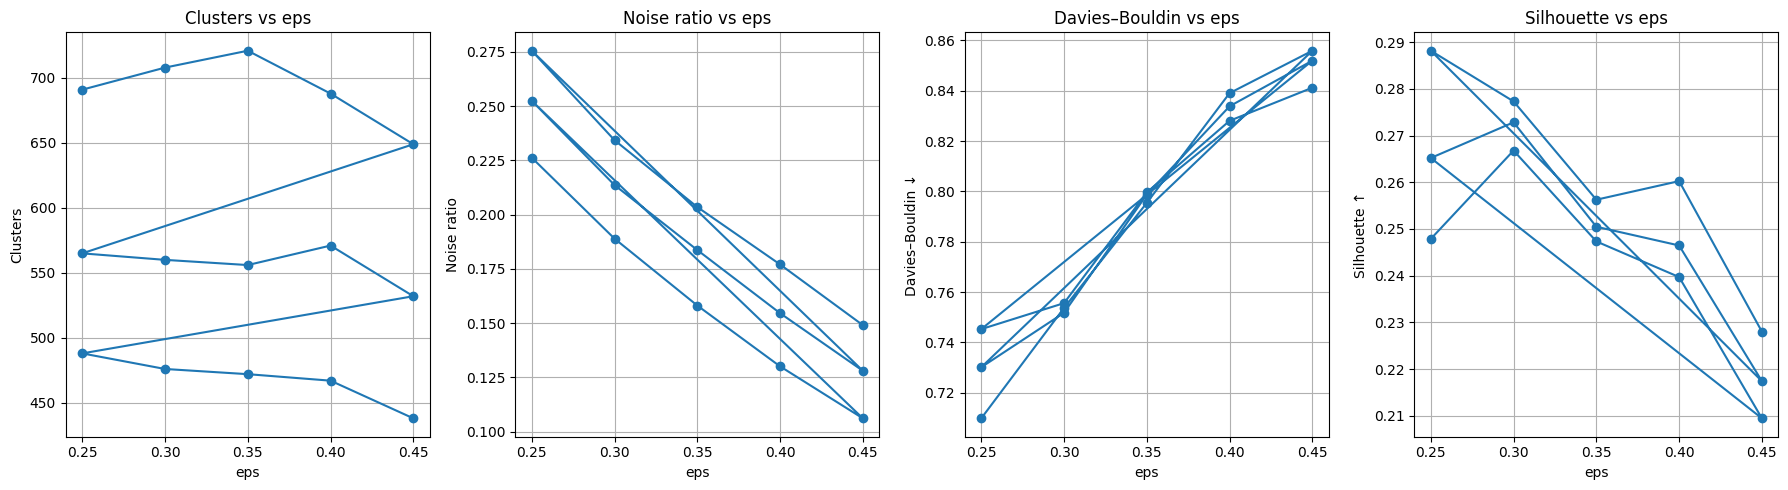

In [21]:
plt.figure(figsize=(18, 5))

# Nombre de clusters
plt.subplot(1, 4, 1)
plt.plot(results_df["eps"], results_df["n_clusters"], "o-")
plt.xlabel("eps")
plt.ylabel("Clusters")
plt.title("Clusters vs eps")
plt.grid(True)

# Bruit
plt.subplot(1, 4, 2)
plt.plot(results_df["eps"], results_df["noise_ratio"], "o-")
plt.xlabel("eps")
plt.ylabel("Noise ratio")
plt.title("Noise ratio vs eps")
plt.grid(True)

# Davies-Bouldin
plt.subplot(1, 4, 3)
plt.plot(results_df["eps"], results_df["davies_bouldin"], "o-")
plt.xlabel("eps")
plt.ylabel("Davies–Bouldin ↓")
plt.title("Davies–Bouldin vs eps")
plt.grid(True)

# Silhouette
plt.subplot(1, 4, 4)
plt.plot(results_df["eps"], results_df["silhouette_avg"], "o-")
plt.xlabel("eps")
plt.ylabel("Silhouette ↑")
plt.title("Silhouette vs eps")
plt.grid(True)

plt.tight_layout()
plt.show()


In [22]:
import os
import numpy as np
import pandas as pd

from hdbscan import HDBSCAN
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score,
    silhouette_score
)
from sklearn.utils import shuffle

# ==============================
# CONFIG
# ==============================
INPUT_CSV = "Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_10.csv"
OUTPUT_DIR = "hdbscan_models_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# PARAMÈTRES À TESTER (800k x 10)
MIN_CLUSTER_SIZE = [50, 100, 200]
MIN_SAMPLES = [10, 20, 30]


SILHOUETTE_SAMPLE_RATIO = 0.1
SILHOUETTE_REPEATS = 3
BASE_RANDOM_STATE = 42

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv(INPUT_CSV)
X = df.values.astype(np.float32)

print("Data shape:", X.shape)
print("✓ Data assumed already normalized")

results = []

# ==============================
# GRID SEARCH HDBSCAN
# ==============================
for min_cluster_size in MIN_CLUSTER_SIZE:
    for min_samples in MIN_SAMPLES:
        print("\n" + "#" * 80)
        print(f"HDBSCAN | min_cluster_size={min_cluster_size} | min_samples={min_samples}")
        print("#" * 80)

        hdbscan = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            core_dist_n_jobs=-1
        )

        labels = hdbscan.fit_predict(X)

        # --------------------------
        # Analyse clusters
        # --------------------------
        n_clusters = len(set(labels) - {-1})
        noise_ratio = np.mean(labels == -1)

        print(f"Clusters (sans bruit): {n_clusters}")
        print(f"Noise ratio: {noise_ratio:.2%}")

        db_index = np.nan
        ch_index = np.nan
        silhouette_avg = np.nan

        # --------------------------
        # Retirer le bruit
        # --------------------------
        mask = labels != -1
        X_clean = X[mask]
        labels_clean = labels[mask]

        if len(np.unique(labels_clean)) >= 2:
            print("→ Computing internal metrics...")

            db_index = davies_bouldin_score(X_clean, labels_clean)
            ch_index = calinski_harabasz_score(X_clean, labels_clean)

            # --------------------------
            # Silhouette (subsampling)
            # --------------------------
            silhouette_scores = []
            sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X_clean))

            for i in range(SILHOUETTE_REPEATS):
                rs = BASE_RANDOM_STATE + i

                X_sub, labels_sub = shuffle(
                    X_clean, labels_clean, random_state=rs
                )

                X_sub = X_sub[:sample_size]
                labels_sub = labels_sub[:sample_size]

                sil = silhouette_score(X_sub, labels_sub)
                silhouette_scores.append(sil)

            silhouette_avg = np.mean(silhouette_scores)

            print(f"Davies-Bouldin: {db_index:.4f}")
            print(f"Calinski-Harabasz: {ch_index:.2f}")
            print(f"Silhouette avg: {silhouette_avg:.4f}")
        else:
            print("⚠ Pas assez de clusters pour calculer les métriques")

        # --------------------------
        # Sauvegarde CSV (cluster par ligne)
        # --------------------------
        clustered_df = df.copy()
        clustered_df["cluster"] = labels

        out_csv = os.path.join(
            OUTPUT_DIR,
            f"data_hdbscan_mcs{min_cluster_size}_ms{min_samples}.csv"
        )
        clustered_df.to_csv(out_csv, index=False)

        print("✓ CSV saved:", out_csv)

        # --------------------------
        # Stocker résultats
        # --------------------------
        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "davies_bouldin": db_index,
            "calinski_harabasz": ch_index,
            "silhouette_avg": silhouette_avg
        })

# ==============================
# SUMMARY
# ==============================
results_df = pd.DataFrame(results)

summary_path = os.path.join(
    OUTPUT_DIR, "hdbscan_metrics_summary.csv"
)
results_df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("FINAL HDBSCAN SUMMARY")
print("=" * 80)
print(results_df)
print("\n✓ Metrics saved to:", summary_path)


Data shape: (211489, 10)
✓ Data assumed already normalized

################################################################################
HDBSCAN | min_cluster_size=50 | min_samples=10
################################################################################
Clusters (sans bruit): 634
Noise ratio: 14.15%
→ Computing internal metrics...
Davies-Bouldin: 0.9669
Calinski-Harabasz: 5202.59
Silhouette avg: 0.2783
✓ CSV saved: hdbscan_models_outputs\data_hdbscan_mcs50_ms10.csv

################################################################################
HDBSCAN | min_cluster_size=50 | min_samples=20
################################################################################
Clusters (sans bruit): 566
Noise ratio: 19.05%
→ Computing internal metrics...
Davies-Bouldin: 0.8951
Calinski-Harabasz: 6231.32
Silhouette avg: 0.3150
✓ CSV saved: hdbscan_models_outputs\data_hdbscan_mcs50_ms20.csv

################################################################################
HDBSCAN

# CLARA

In [5]:
SILHOUETTE_SAMPLE_RATIO = 0.1  # Adjust based on your memory/time constraints
SILHOUETTE_REPEATS = 3
BASE_RANDOM_STATE = 42

In [ ]:
df = unsupervised_feature_reduction_kmeans(csv_path="Cleaned_dataset/unsupervised/data.csv")
print(df.shape)
print(df.columns)

X = df.values

def clara_cost(X, medoids):
    distances = pairwise_distances(X, medoids)
    return np.sum(np.min(distances, axis=1))

def CLARA(X, k, n=5, s=None, random_state=42):
    """
    X : array-like, shape (N, d)
    k : number of clusters
    n : number of samples
    s : sample size (default = 40 + 2k)
    """

    np.random.seed(random_state)
    N = X.shape[0]

    if s is None:
        s = min(N, 40 + 2 * k)

    best_cost = np.inf
    best_medoids = None

    # ---- for i = 1 to n ----
    for i in range(n):

        # S_i ← RandomSample(X, s)
        indices = np.random.choice(N, s, replace=False)
        S_i = X[indices]

        # (A_i, C_i) ← PAM(S_i, k)
        pam = KMedoids(
            n_clusters=k,
            method="pam",
            init="k-medoids++",
            random_state=random_state
        )
        pam.fit(S_i)

        C_i = pam.cluster_centers_

        # Evaluate medoids on full dataset
        cost = clara_cost(X, C_i)

        if cost < best_cost:
            best_cost = cost
            best_medoids = C_i

    # C ← Best(C1, ..., Cn)
    C = best_medoids

    # A ← AssignPointsToNearestMedoid(X, C)
    distances = pairwise_distances(X, C)
    A = np.argmin(distances, axis=1)

    return A, C


Initial features: 58
After Variance Filter: 47
After Clustering: 32
(211489, 32)
Index(['PH_WATER', 'ORG_CARBON', 'CN_RATIO', 'CLAY', 'GRIDCODE_200.0',
       'fire_count', 'elevation', 'spring_tmin', 'CEC_EFF', 'GRIDCODE_130.0',
       'GRIDCODE_20.0', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'spring_tmax',
       'TEXTURE_SOTER_C', 'ESP', 'GRIDCODE_201.0', 'GRIDCODE_150.0', 'COARSE',
       'ALUM_SAT', 'autumn_prec', 'SILT', 'summer_prec', 'GRIDCODE_14.0',
       'GRIDCODE_151.0', 'BULK', 'winter_prec', 'GRIDCODE_30.0', 'CEC_CLAY',
       'GRIDCODE_50.0', 'spring_prec', 'GRIDCODE_110.0'],
      dtype='object')


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6]
Nombre clusters effectifs: 7


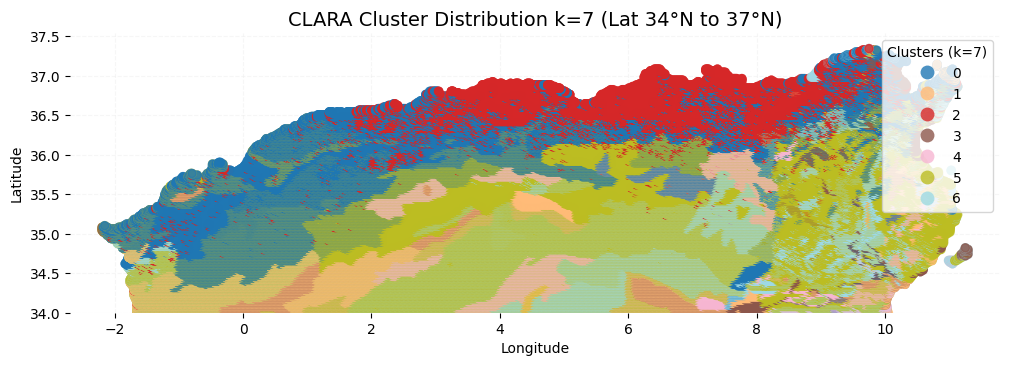

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.3423
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 112148.2940
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.2120
  Subset 2 | random_state=43
    Silhouette score: 0.2131
  Subset 3 | random_state=44
    Silhouette score: 0.2141
→ Average Silhouette (K=7): 0.2131


c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\melom\OneDrive\Desktop\Data mining\clara_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative

Labels uniques: [0, 1, 2, 3, 4, 5, 6, 7]
Nombre clusters effectifs: 8


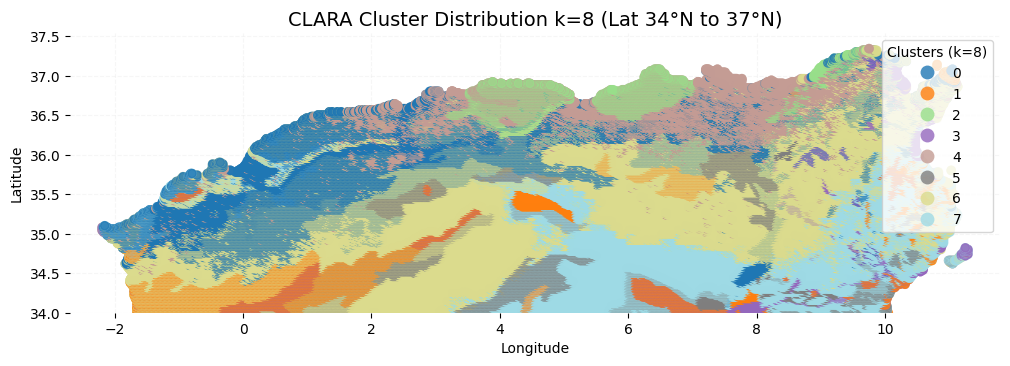

→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 1.2152
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 141003.4397
→ Silhouette evaluation on 3 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.2034
  Subset 2 | random_state=43
    Silhouette score: 0.2027
  Subset 3 | random_state=44
    Silhouette score: 0.2011
→ Average Silhouette (K=8): 0.2024


In [7]:
for k in range(7, 9):

    labels_full, medoids = CLARA(X, k=k, n=10, s=80, random_state=BASE_RANDOM_STATE)

    print(f"Labels uniques: {sorted(np.unique(labels_full))}")
    print(f"Nombre clusters effectifs: {len(np.unique(labels_full))}")

    # Combine original coordinates with new CLARA labels
    plot_df = coords.copy()
    plot_df['cluster'] = labels_full

        # Filter Latitude > 34
    df_filtered = plot_df[plot_df[lat_col] > 34].copy()

        # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
            df_filtered, 
            geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
            crs="EPSG:4326"
        )

        # Plot clusters
    fig, ax = plt.subplots(figsize=(12, 12)) 
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)
    gdf.plot(column='cluster', 
                ax=ax, 
                categorical=True, 
                legend=True, 
                cmap='tab20', 
                markersize=35,      
                alpha=0.8,          
                zorder=2,
                legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)
    for spine in ax.spines.values():
            spine.set_visible(False)
    plt.title(f"CLARA Cluster Distribution k={k} (Lat 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)
    plt.show()


    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
            rs = BASE_RANDOM_STATE + i
            print(f"  Subset {i+1} | random_state={rs}")

            X_sub, labels_sub = shuffle(
                X, labels_full, random_state=rs
            )

            X_sub = X_sub[:sample_size]
            labels_sub = labels_sub[:sample_size]

            sil = silhouette_score(
                X_sub, labels_sub, metric="euclidean"
            )

            silhouette_scores.append(sil)
            print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")
